In [12]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(r'mall - mall.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df = df.drop(columns= ['CustomerID', 'Genre'])
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [15]:
x = df.iloc[:, [0,1]].values

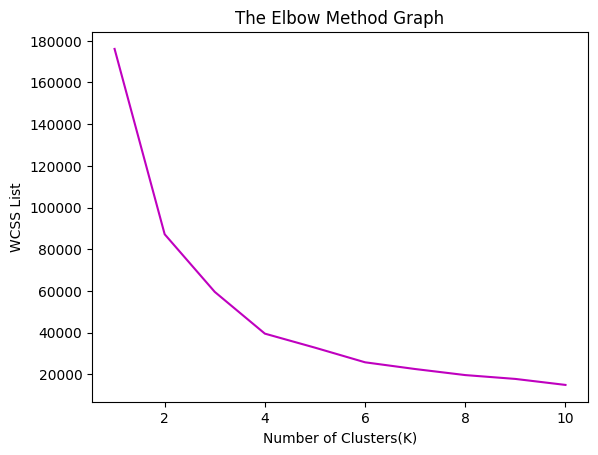

In [25]:
a = []

for i in range(1, 11):
    b = KMeans(n_clusters= i, init= 'k-means++', random_state=42)
    b.fit(x)
    a.append(b.inertia_)

plt.plot(range(1,11), a, c='m')

plt.title("The Elbow Method Graph")
plt.xlabel("Number of Clusters(K)")
plt.ylabel('WCSS List')
plt.show()

### **From the above plot we can see the elbow point is 4, so the number of clusters will be 4**

In [18]:
b = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_pred = b.fit_predict(x)

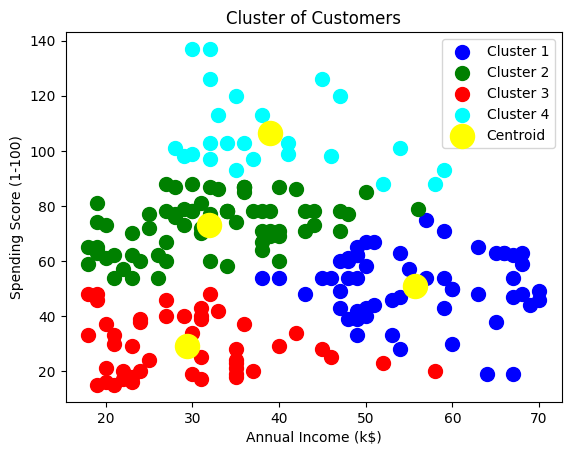

In [19]:
## Visulaizing the Cluster
plt.scatter(x[y_pred == 0, 0], x[y_pred == 0, 1], s=100, c='blue', label="Cluster 1")
plt.scatter(x[y_pred == 1, 0], x[y_pred == 1, 1], s=100, c='green', label="Cluster 2")
plt.scatter(x[y_pred == 2, 0], x[y_pred == 2, 1], s=100, c='red', label="Cluster 3")
plt.scatter(x[y_pred == 3, 0], x[y_pred == 3, 1], s=100, c='cyan', label="Cluster 4")

plt.scatter(b.cluster_centers_[:, 0], b.cluster_centers_[:, 1], s = 300, c="yellow", label="Centroid")
plt.title("Cluster of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()